In [4]:
import torch

# 1. GPU 사용 가능 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. 텐서 생성 및 Gradient 추적 활성화
x = torch.ones(1, requires_grad=True, device=device)

# 3. 간단한 연산 (y = x^2 + 3)
y = x ** 2 + 3

# 4. 백워드(Backward) 실행
y.backward()

# 5. 결과 확인 (dy/dx = 2x, x=1 이므로 결과는 2.0이어야 함)
print(f"Forward result: {y.item()}")
print(f"Backward gradient: {x.grad.item()}")

if x.grad.item() == 2.0:
    print("\n✅ CUDA Backward Test Passed!")
else:
    print("\n❌ Something is wrong.")

Using device: cuda
Forward result: 4.0
Backward gradient: 2.0

✅ CUDA Backward Test Passed!


In [5]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/blue2959/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [6]:
import os
os.cpu_count()

64

In [1]:
import torch

sd = torch.load("/home/blue2959/monotonic_tts/ljspeech_runs/attn_aligner_20260319-042555/checkpoints/ckpt_step_246000.pth")

In [4]:
sd["model"]["text_encoder.emb.weight"].shape

torch.Size([256, 128])

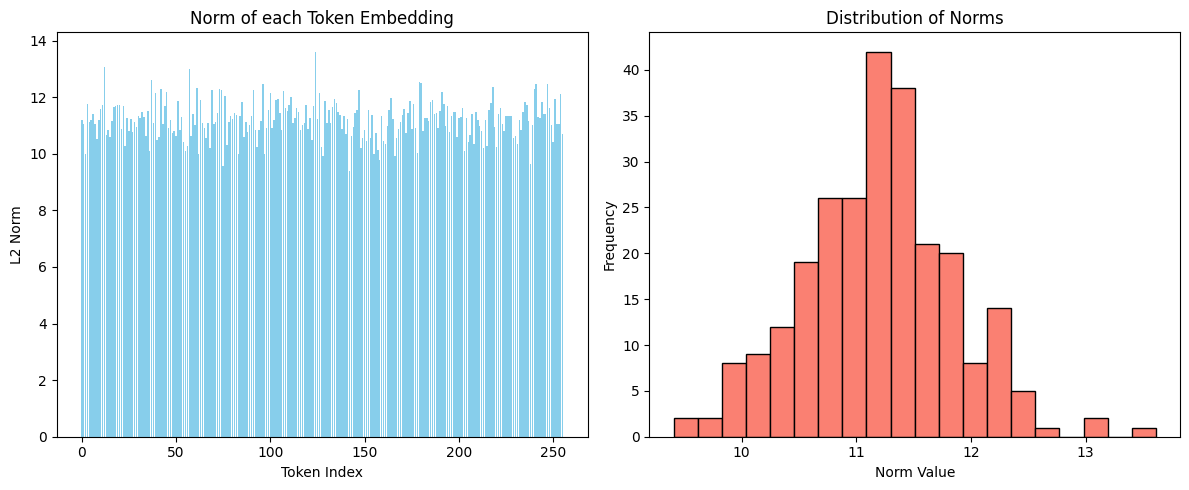

In [8]:
import torch
import matplotlib.pyplot as plt

# 데이터 모사 (가져오신 shape 기준)
weight = torch.randn(256, 128)

# L2 Norm 계산 (dim=1은 각 단어 벡터의 길이를 계산함)
norms = torch.norm(weight, p=2, dim=1).detach().cpu().numpy()

# 시각화
plt.figure(figsize=(12, 5))

# 1. 막대 그래프 (각 토큰별 Norm)
plt.subplot(1, 2, 1)
plt.bar(range(len(norms)), norms, color='skyblue')
plt.title("Norm of each Token Embedding")
plt.xlabel("Token Index")
plt.ylabel("L2 Norm")

# 2. 히스토그램 (Norm의 분포)
plt.subplot(1, 2, 2)
plt.hist(norms, bins=20, color='salmon', edgecolor='black')
plt.title("Distribution of Norms")
plt.xlabel("Norm Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

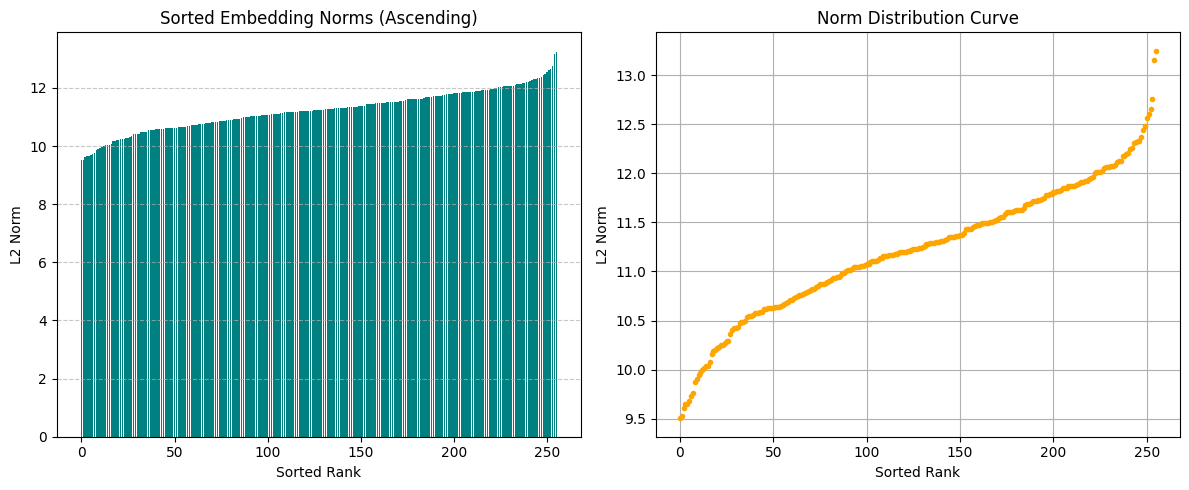

Top 5 Indices (Highest Norm): [108, 153, 241, 175, 170]


In [ ]:
import torch
import matplotlib.pyplot as plt

# 기존 데이터 (가져오신 텐서라고 가정)
# weight = sd["model"]["text_encoder.emb.weight"]
weight = torch.randn(256, 128) # 예시 데이터

# 1. L2 Norm 계산
norms = torch.norm(weight, p=2, dim=1)

# 2. 정렬 (오름차순)
sorted_norms, sorted_indices = torch.sort(norms)

# 시각화를 위해 numpy 변환
sorted_norms_np = sorted_norms.detach().cpu().numpy()

# 3. 시각화
plt.figure(figsize=(12, 5))

# 정렬된 막대 그래프
plt.subplot(1, 2, 1)
plt.bar(range(len(sorted_norms_np)), sorted_norms_np, color='teal')
plt.title("Sorted Embedding Norms (Ascending)")
plt.xlabel("Sorted Rank")
plt.ylabel("L2 Norm")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 누적 분포 (CDF 느낌으로 확인)
plt.subplot(1, 2, 2)
plt.plot(sorted_norms_np, marker='.', linestyle='none', color='orange')
plt.title("Norm Distribution Curve")
plt.xlabel("Sorted Rank")
plt.ylabel("L2 Norm")
plt.grid(True)

plt.tight_layout()
plt.show()

# 팁: 가장 Norm이 큰 상위 5개 인덱스 출력
print(f"Top 5 Indices (Highest Norm): {sorted_indices[-5:].tolist()}")